<a href="https://colab.research.google.com/github/omieibifiberesima-web/ecg-arrhythmia-classification/blob/main/ECG_Arrhythmia_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECG Arrhythmia Classification from Heartbeat Features

A machine learning project exploring whether individual heartbeat measurements
can be used to classify ECG rhythms as Normal, Supraventricular, or Ventricular
arrhythmia — with particular focus on the challenge of detecting rare but
clinically significant arrhythmia types in a heavily imbalanced, real-world
clinical dataset.

Dataset: MIT-BIH Arrhythmia Database (100,604 heartbeats from 48 patients,
pre-extracted numeric features)


In [1]:
import pandas as pd

df = pd.read_csv('Cardiac_arrhythmia_dataset.csv')
df.head()

,rr_prev,rr_next,rr_ratio,amp_max,amp_min,amp_mean,amp_std,amp_range,skew,kurtosis,label,record
0,0.163889,0.813889,0.201365,0.84,-0.485,-0.231319,0.286818,1.325,2.711073,6.539603,Normal,100
1,0.813889,0.811111,1.003425,0.94,-0.535,-0.245556,0.348851,1.475,2.427790,4.808831,Normal,100
2,0.811111,0.788889,1.028169,0.96,-0.570,-0.291875,0.326277,1.530,2.805602,7.067556,Normal,100
3,0.788889,0.791667,0.996491,0.86,-0.645,-0.316181,0.316316,1.505,2.665703,6.461823,Normal,100
4,0.791667,0.788889,1.003521,0.82,-0.565,-0.302361,0.289162,1.385,2.857818,7.455739,Normal,100


## Exploring the Data

The dataset contains 100,604 individual heartbeats from 48 patients, each
described by 10 numeric features (timing between beats, waveform amplitude
and shape statistics), along with a diagnostic label: Normal, Supraventricular,
or Ventricular arrhythmia.

In [2]:
df['label'].value_counts()

,count
label,
Normal,90589
Ventricular,7236
Supraventricular,2779


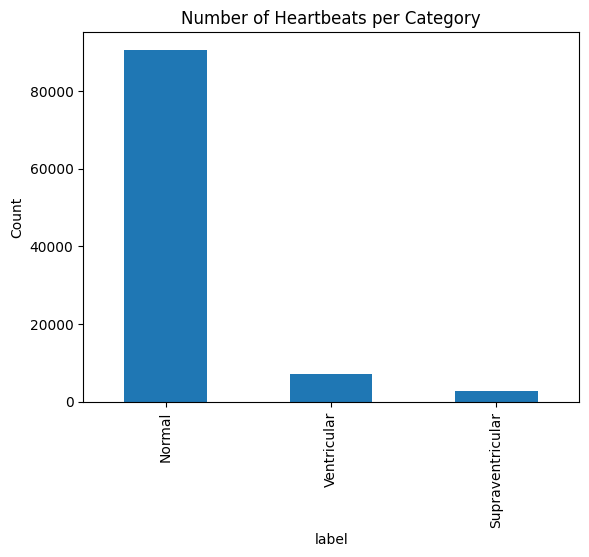

In [3]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title('Number of Heartbeats per Category')
plt.ylabel('Count')
plt.show()

## A Severely Imbalanced, but Realistic, Dataset

The class distribution is heavily skewed: approximately 90% of heartbeats are
Normal, 7% are Ventricular, and under 3% are Supraventricular. While extreme,
this imbalance reflects real clinical reality — arrhythmias are, by definition,
rare relative to normal heart rhythm. Rather than seeking out an artificially
balanced dataset, I chose to work with this realistic distribution, since
learning to build models that remain useful under real-world class imbalance
is itself one of the central challenges in clinical machine learning.

In [4]:
df['record'].nunique()

48

In [5]:
unique_patients = df['record'].unique()

import numpy as np
np.random.seed(42)
np.random.shuffle(unique_patients)

test_patients = unique_patients[:10]
train_patients = unique_patients[10:]

train_df = df[df['record'].isin(train_patients)]
test_df = df[df['record'].isin(test_patients)]

print(f"Training patients: {len(train_patients)}, Training heartbeats: {len(train_df)}")
print(f"Testing patients: {len(test_patients)}, Testing heartbeats: {len(test_df)}")

Training patients: 38, Training heartbeats: 80182
Testing patients: 10, Testing heartbeats: 20422


## Splitting by Patient to Avoid Data Leakage

Since multiple heartbeats come from the same 48 patients, a random row-level
train/test split risks data leakage: the model could learn to recognize
individual patients' unique heart rhythm characteristics rather than general
arrhythmia patterns, artificially inflating test performance. To avoid this,
I split the data by patient — training on 38 patients and testing on 10
entirely unseen patients — providing a more clinically honest evaluation of
how the model would perform on a new patient it has never encountered.

In [6]:
feature_cols = ['rr_prev', 'rr_next', 'rr_ratio', 'amp_max', 'amp_min', 'amp_mean', 'amp_std', 'amp_range', 'skew', 'kurtosis']

X_train = train_df[feature_cols]
y_train = train_df['label']

X_test = test_df[feature_cols]
y_test = test_df['label']

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, rf_predictions))
print(classification_report(y_test, rf_predictions))

[[18089   166   956]
 [  283    31    97]
 [  244    12   544]]
                  precision    recall  f1-score   support

          Normal       0.97      0.94      0.96     19211
Supraventricular       0.15      0.08      0.10       411
     Ventricular       0.34      0.68      0.45       800

        accuracy                           0.91     20422
       macro avg       0.49      0.57      0.50     20422
    weighted avg       0.93      0.91      0.92     20422



## Baseline Model: Random Forest with Class Weighting

Using a Random Forest classifier with class weighting to help address the
imbalance, the model achieved 91% overall accuracy. However, this figure is
misleading: recall for Supraventricular arrhythmia — the rarest class — was
only 8%, meaning the model missed 92% of true Supraventricular cases. Recall
for Ventricular arrhythmia was more reasonable at 68%. This illustrates a
core risk in imbalanced clinical classification: high overall accuracy can
mask near-total failure to detect the rarest, and often most clinically
urgent, condition.

In [9]:
!pip install imbalanced-learn --quiet
from imblearn.over_sampling import SMOTE

In [12]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

y_train_smote.value_counts()

,count
label,
Normal,71378
Supraventricular,71378
Ventricular,71378


In [13]:
rf_model_smote = RandomForestClassifier(random_state=42)
rf_model_smote.fit(X_train_smote, y_train_smote)

rf_predictions_smote = rf_model_smote.predict(X_test)

print(confusion_matrix(y_test, rf_predictions_smote))
print(classification_report(y_test, rf_predictions_smote))

[[16984   870  1357]
 [  210    92   109]
 [  157    29   614]]
                  precision    recall  f1-score   support

          Normal       0.98      0.88      0.93     19211
Supraventricular       0.09      0.22      0.13       411
     Ventricular       0.30      0.77      0.43       800

        accuracy                           0.87     20422
       macro avg       0.46      0.63      0.50     20422
    weighted avg       0.93      0.87      0.89     20422



## Addressing the Imbalance with SMOTE

To improve detection of the minority classes, I applied SMOTE (Synthetic
Minority Oversampling Technique) to the training data only, generating
synthetic examples of the rarer arrhythmia types to better balance the
training set, while leaving the test set untouched and realistically
imbalanced.

This nearly tripled Supraventricular recall, from 8% to 22%, and improved
Ventricular recall from 68% to 77%. However, this came at a real cost:
overall accuracy dropped from 91% to 87%, and precision for Supraventricular
remained low (9%), meaning most Supraventricular predictions were still
false alarms.

This represents a genuine clinical trade-off rather than a clean
improvement: the model became substantially better at catching a rare,
dangerous condition, at the cost of more false positives and reduced
overall accuracy — a trade-off that may be appropriate in a screening
context, but highlights that this approach alone is not yet reliable
enough for real clinical deployment.

## Conclusion

This project highlights one of the central challenges in applying machine
learning to real clinical data: severe class imbalance can make rare but
critical conditions nearly invisible to a model, even when overall accuracy
appears strong. Using a patient-level train/test split to ensure a clinically
honest evaluation, I found that a Random Forest classifier struggled
substantially to detect Supraventricular arrhythmia, and that SMOTE-based
resampling meaningfully improved — but did not solve — this problem,
trading overall accuracy and precision for improved sensitivity to rare
arrhythmia types.

Rather than a finished diagnostic tool, this project demonstrates a realistic,
honestly-evaluated exploration of the difficulties involved in detecting
rare clinical events from imbalanced real-world data — directly relevant to
the kind of decision-support and predictive modeling challenges present in
real healthcare applications.